<a href="https://colab.research.google.com/github/TorbjornLarsson/SCDA/blob/main/Miniproject_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Miniproject 2 work sheet

Classification of handwritten digits is a standard problem in pattern recognition. This miniproject aims to practice a classification technique using SVD.

***SVD-based classification***

Task 1:
Let δ be a an image of a digit of size m outside the training set (which is called a test digit). It is reasonable to assume that δ can be well represented in terms of singular images {u_1, . . . ,u_k} of its own kind with a relatively small residual. We must compute how well δ can be represented in the 10 different bases, each corresponding to one of the digits 0, 1, . . . , 9. This can be done by computing the residual vector in the least squares problems of the type min x ∥U_k x − δ∥_2 (0.2) where δ represents a test digit and U_k is a m × k matrix consisting of the first k columns of U.

We can show that the solution of least squares problem (0.2) is x = U_k^T δ and the residual is residual = ∥(I – U_k U_k^T )δ∥_2. (0.3)

Let U_k∈R^(m×k) have orthonormal columns (it’s the first k left singular vectors, so U_k^T U_k=I_k). Consider
(min⁡)┬x∥U_k x-δ∥_2.

It’s equivalent (same minimiser) to minimising the square:
f(x)=∥U_k x-δ∥_2^2=(U_k x-δ)^T (U_k x-δ).

1) Solve for x
Differentiate and set the gradient to zero:
∇f(x)=2U_k^T (U_k x-δ)=0
⇒U_k^T U_k x=U_k^T δ
⇒I_k x=U_k^T δ
so
(x=U_k^T δ.)

2) Express the residual
Plug this back into the fitted vector:
δ ̂=U_k x=U_k U_k^T δ.

Hence the residual vector is
r=δ-δ ̂=δ-U_k U_k^T δ=(I-U_k U_k^T)δ,

and its 2-norm is
(∥r∥_2=∥(I-U_k U_k^T)δ∥_2.)

Interpretation: U_k U_k^T is the orthogonal projector onto span{u_1,…,u_k}, so the residual is the length of the component of δorthogonal to that subspace.


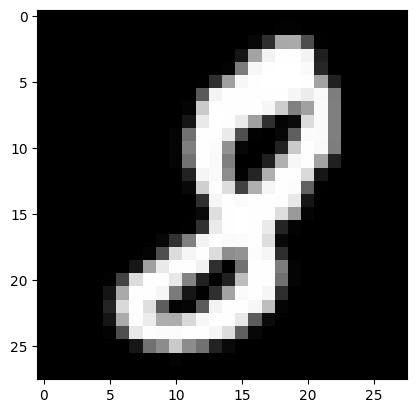

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Show a training image
TrainMat = np.load('TrainDigits.npy')
d = TrainMat[:,0] # The first digit in the training set
D = np.reshape(d, (28, 28)).T # Reshaping a vector to a matrix
plt.imshow(D, cmap ='gray') # Plot of the digit

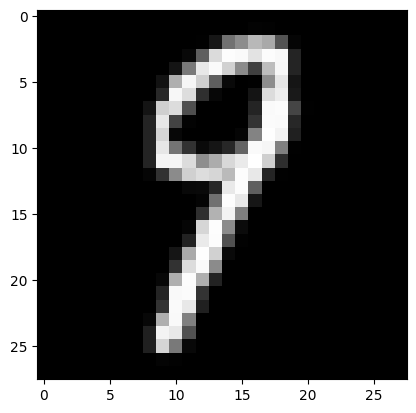

In [29]:
# Show a test image
TestMat = np.load('TestDigits.npy')
d = TestMat[:,1] # A digit in the training set
D = np.reshape(d, (28, 28)).T # Reshaping a vector to a matrix
plt.imshow(D, cmap ='gray') # Plot of the digit

Task 2: For training matrices of digits 3 and 8 (each of size 784 × 400), compute the SVD and plot the singular values (one plot for each digit). Use linear scales for both axes. Report your observation and try to justify it. Also plot the first three singular images u1,u2,u3 for digits 3 and 8, separately (six plots), and report your observation. To plot a singular image, you can modify the code used for plotting the
first digit of the training set in the next section.

Number of images labeled '3': 24000


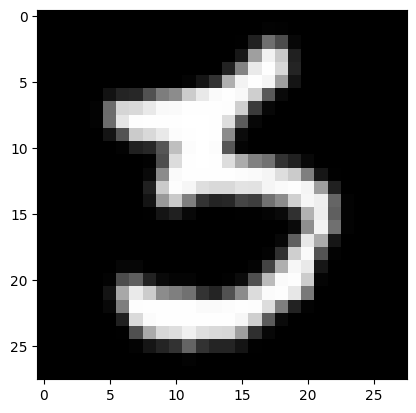

In [30]:
TrainLab = np.load('TrainLabels.npy')

# Extract 400 training digits labeled '3'.
index = (TrainLab == 3); # find train digits of type 3
print("Number of images labeled '3':", np.sum(index))
A3 = TrainMat[:,index[0]] # all train digits of type 3
A3 = A3[:,0:400] # the first 400 train digits of type 3

# Plot an image
d = A3[:,0] # Pick a digit
D = np.reshape(d, (28, 28)).T # Reshaping a vector to a matrix
plt.imshow(D, cmap ='gray') # Plot of the digit

Number of images labeled '8': 24000


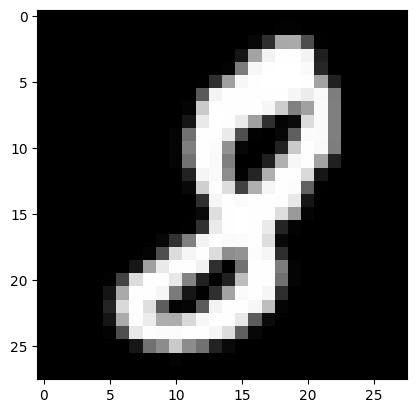

In [31]:
TrainLab = np.load('TrainLabels.npy')

# Extract 400 training digits labeled '8'.
index = (TrainLab == 8); # find train digits of type 8
print("Number of images labeled '8':", np.sum(index))
A8 = TrainMat[:,index[0]] # all train digits of type 8
A8 = A8[:,0:400] # the first 400 train digits of type 8

# Plot an image
d = A8[:,0] # Pick a digit
D = np.reshape(d, (28, 28)).T # Reshaping a vector to a matrix
plt.imshow(D, cmap ='gray') # Plot of the digit

First singular value for '3': [43351.74282887]
First singular value for '8': [44742.58576521]


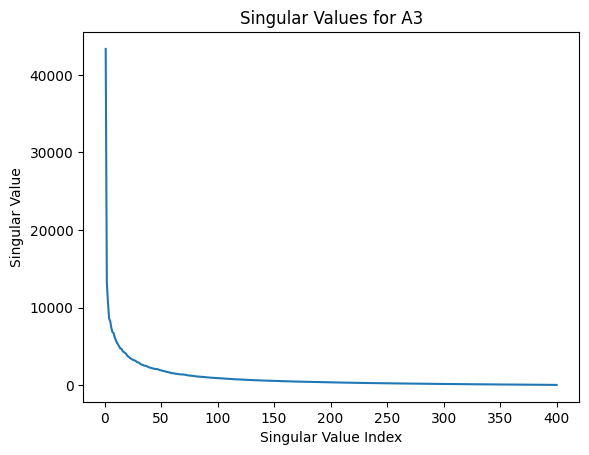

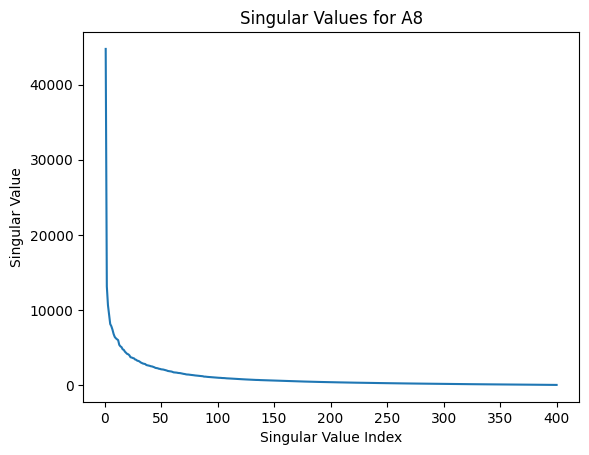

In [32]:
# For the training matrices A3 of digits 3 and A8 of digits 8 (each of size 784 × 400),
# compute the SVD and plot the singular values (one plot for each digit).
# Use linear scales for both axes.

# Plot for A3
U_A3, S3, V_A3t = np.linalg.svd(A3, full_matrices=True)
plt.figure() # Create a new figure for A3
x3 = np.arange(1, len(S3) + 1)
plt.plot(x3, S3)
plt.title("Singular Values for A3")
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
print("First singular value for '3':", S3[:1])

# Plot for A8
U_A8, S8, V_A8t = np.linalg.svd(A8, full_matrices=True)
plt.figure() # Create a new figure for A8
x8 = np.arange(1, len(S8) + 1)
plt.plot(x8, S8)
plt.title("Singular Values for A8")
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
print("First singular value for '8':", S8[:1])

Report your observation and try to justify it.

The fast drop in singular value decompositions can be expected for images, since they can often be compressed by using the first values in a reconstruction.

Also plot the first three
singular images u1,u2,u3 for digits 3 and 8, separately (six plots), and report your
observation.

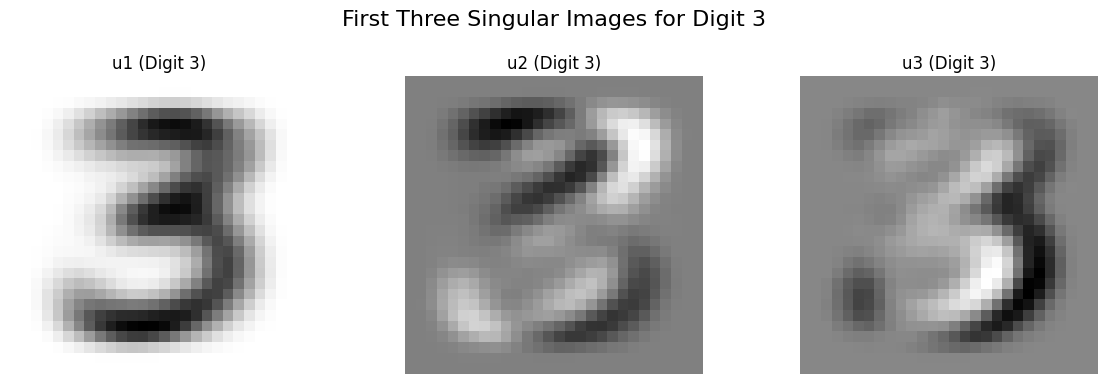

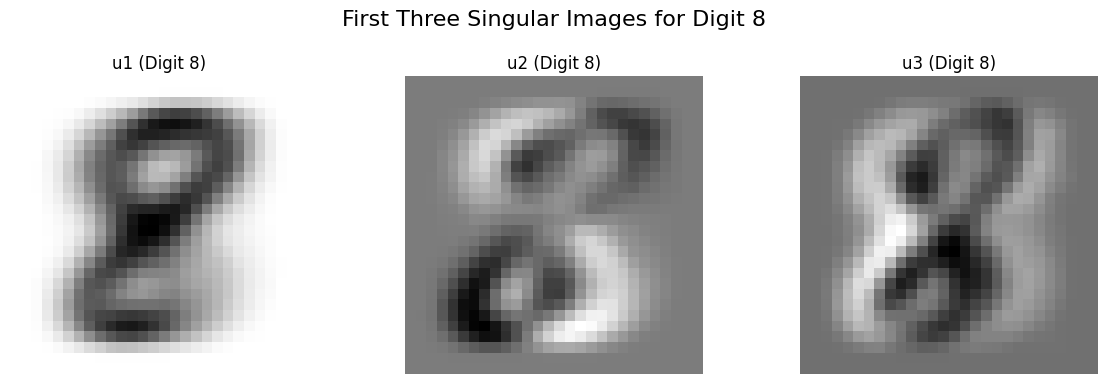

In [33]:
# Plot the first three singular images u1,u2,u3 for digits 3 and 8.

def plot_singular_image(vector, title, ax):
    image = np.reshape(vector, (28, 28)).T
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

# For digit 3
plt.figure(figsize=(12, 4))
plt.suptitle('First Three Singular Images for Digit 3', fontsize=16)

ax1 = plt.subplot(1, 3, 1)
plot_singular_image(U_A3[:, 0], 'u1 (Digit 3)', ax1)

ax2 = plt.subplot(1, 3, 2)
plot_singular_image(U_A3[:, 1], 'u2 (Digit 3)', ax2)

ax3 = plt.subplot(1, 3, 3)
plot_singular_image(U_A3[:, 2], 'u3 (Digit 3)', ax3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# For digit 8
plt.figure(figsize=(12, 4))
plt.suptitle('First Three Singular Images for Digit 8', fontsize=16)

ax4 = plt.subplot(1, 3, 1)
plot_singular_image(U_A8[:, 0], 'u1 (Digit 8)', ax4)

ax5 = plt.subplot(1, 3, 2)
plot_singular_image(U_A8[:, 1], 'u2 (Digit 8)', ax5)

ax6 = plt.subplot(1, 3, 3)
plot_singular_image(U_A8[:, 2], 'u3 (Digit 8)', ax6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Singulära bilder (som du just har plottat, u1, u2, u3, etc.) är de vänstra singulära vektorerna från SVD av en uppsättning bilder för en specifik siffra. De bildar en ortogonal bas för det underrum som bäst representerar den siffra de kommer ifrån. De kan användas för klassificering på följande sätt:

Representera varje sifferklass med sin egen 'bas': För varje siffra (0 till 9) beräknar vi SVD på dess träningsbilder. Detta ger oss en uppsättning singulära vektorer (U_k) för varje sifferklass. Dessa U_k-matriser fungerar som en 'bas' för att beskriva bilder av just den siffran.

Projicera en testbild på varje bas: När du får en okänd testbild (δ) som du vill klassificera, projicerar du den på varje sifferklass' bas. En projektion innebär att du försöker representera δ så bra som möjligt med en linjärkombination av de singulära bilderna för den sifferklassen.

Beräkna residualen: Efter projektionen får du en 'återskapad' bild av δ baserad på den specifika sifferklassens bas. Skillnaden mellan den ursprungliga testbilden δ och den återskapade bilden kallas residualen (r). Denna residual är den del av δ som inte kan representeras av den valda sifferklassens bas.

Matematiskt beräknas 2-normen av residualen som: ||r||_2 = ||(I – U_k U_k^T )δ||_2 (som det står i Task 1 i din notebook). Denna norm representerar 'längden' av den ortogonala komponenten av δ i förhållande till underrummet som spänns av U_k. Ju mindre residual, desto bättre passar testbilden in i den sifferklassen.

Klassificera baserat på minsta residual: Du upprepar steg 2 och 3 för alla sifferklasser (0 till 9). Den sifferklass vars bas resulterar i den minsta residualnormen är den siffra som testbilden troligen föreställer. Tanken är att en '3'a ska passa bäst in i '3'ans bas, en '8'a i '8'ans bas, och så vidare, och därmed ge den minsta residualen för sin 'rätta' klass.



3. You must precompute all ten SVDs and store U_k matrices for all ten digits (store U_k for maximum k, here 15, and then pick up smaller subsets for k = 5, 6, . . . , 15. You can use e.g. a dictionary for storing). Then use the precomputed matrices for all 40000 test digits.


In [34]:
# Precompute all ten SVDs and store U_k matrices for all ten digits
Uk_matrices = {}
max_k = 15 # As specified in the task

for digit in range(10):
    # Extract training digits for the current digit
    index = (TrainLab == digit)
    A_digit = TrainMat[:, index[0]]

    # Take the first 400 instances if available, or fewer if not enough
    # The task specifies 'each of size 784 x 400', assuming we take up to 400 training examples per digit
    if A_digit.shape[1] > 400:
        A_digit = A_digit[:, :400]
    elif A_digit.shape[1] == 0:
        print(f"Warning: No training examples found for digit {digit}. Skipping SVD.")
        continue

    # Perform SVD
    # We only need U, and we can truncate it later if needed for a specific k
    U_digit, s_digit, vt_digit = np.linalg.svd(A_digit, full_matrices=False)

    # Store the U matrix (or its first max_k columns)
    # It's better to store enough and slice later than to store too little
    Uk_matrices[digit] = U_digit[:, :max_k]

print("Uk_matrices dictionary created with U_k for each digit (first 15 singular vectors).")
print("Keys in Uk_matrices:", Uk_matrices.keys())

Uk_matrices dictionary created with U_k for each digit (first 15 singular vectors).
Keys in Uk_matrices: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [36]:
print("Nycklar i Uk_matrices:", Uk_matrices.keys())
print("Formen på U_k-matrisen för siffra 0 (den första i ordlistan, om den finns):", Uk_matrices[0].shape)

Nycklar i Uk_matrices: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Formen på U_k-matrisen för siffra 0 (den första i ordlistan, om den finns): (784, 15)


The equations you need are formulated for a single test vector δ (one “flattened” test image). But if you use that approach in your code, it will take a
very long time to run. In contrast, matrix-matrix multiplications are much more efficient
on modern computers. To take full advantage of that, simply replace vector δ in Equation
(0.3) with the entire test matrix. Then you can apply np.linalg.norm(..,axis = 0) to
get residuals for all test points, in one vector of length 40000.


In [ ]:
#The equations you need are formulated for a single test vector δ (one “flattened” test image).
# But if you use that approach in your code, it will take a
# very long time to run. In contrast, matrix-matrix multiplications are much more efficient
# on modern computers. To take full advantage of that, simply replace vector δ in Equation
# (0.3) with the entire test matrix. Then you can apply np.linalg.norm(..,axis = 0) to
# get residuals for all test points, in one vector of length 40000.

In [37]:
TestMat = np.load('TestDigits.npy')
TestLabels = np.load('TestLabels.npy')

def calculate_residuals(test_data, U_k_matrix_for_digit, k):
    """
    Calculate the 2-norm of the residuals for test_data against a given U_k_matrix_for_digit.

    Args:
        test_data (np.ndarray): The matrix of test digits (m x num_test_digits).
        U_k_matrix_for_digit (np.ndarray): The U_k matrix for a specific digit class (m x max_k).
        k (int): The number of singular vectors to use (truncation).

    Returns:
        np.ndarray: A vector of residuals, one for each test digit (length num_test_digits).
    """
    U_k_truncated = U_k_matrix_for_digit[:, :k]

    # The projection matrix P = U_k @ U_k.T
    P_k = U_k_truncated @ U_k_truncated.T

    # Residual matrix: (I - P_k) @ test_data
    # np.eye(test_data.shape[0]) creates an identity matrix of size m x m
    residual_matrix = (np.eye(test_data.shape[0]) - P_k) @ test_data

    # Calculate the 2-norm of each column (each test digit's residual)
    residuals = np.linalg.norm(residual_matrix, axis=0)
    return residuals

def classify_and_evaluate(test_mat, test_labels, Uk_matrices_all_digits, k_value):
    """
    Classify test digits using SVD-based method and evaluate accuracy.

    Args:
        test_mat (np.ndarray): The matrix of test digits (m x num_test_digits).
        test_labels (np.ndarray): True labels for test digits.
        Uk_matrices_all_digits (dict): Dictionary with U_k matrices for all digits.
        k_value (int): The number of singular vectors to use for classification.

    Returns:
        float: Classification accuracy.
    """
    num_test_digits = test_mat.shape[1]
    num_classes = len(Uk_matrices_all_digits)

    # Store residuals for each test digit against each class
    all_residuals = np.zeros((num_classes, num_test_digits))

    for digit_class in range(num_classes):
        if digit_class in Uk_matrices_all_digits:
            U_k_for_class = Uk_matrices_all_digits[digit_class]
            all_residuals[digit_class, :] = calculate_residuals(test_mat, U_k_for_class, k_value)
        else:
            # Handle cases where a digit might not have been processed (though it should be for 0-9)
            print(f"Warning: U_k matrix not found for digit {digit_class}. Setting residuals to infinity.")
            all_residuals[digit_class, :] = np.inf

    # For each test digit, find the class with the minimum residual
    predicted_labels = np.argmin(all_residuals, axis=0)

    # Evaluate accuracy
    correct_predictions = np.sum(predicted_labels == test_labels[0]) # TestLabels might be (1, 10000)
    accuracy = correct_predictions / num_test_digits

    return accuracy

print("Test data loaded. Classification functions defined.")

Test data loaded. Classification functions defined.


Nu ska vi beräkna noggrannheten för olika värden på `k` (antalet singulära vektorer som används) och visualisera hur noggrannheten varierar.

Starting classification for k values from 5 to 15...
k = 5: Accuracy = 0.9181
k = 6: Accuracy = 0.9233
k = 7: Accuracy = 0.9302
k = 8: Accuracy = 0.9341
k = 9: Accuracy = 0.9387
k = 10: Accuracy = 0.9400
k = 11: Accuracy = 0.9414
k = 12: Accuracy = 0.9436
k = 13: Accuracy = 0.9453
k = 14: Accuracy = 0.9465
k = 15: Accuracy = 0.9469


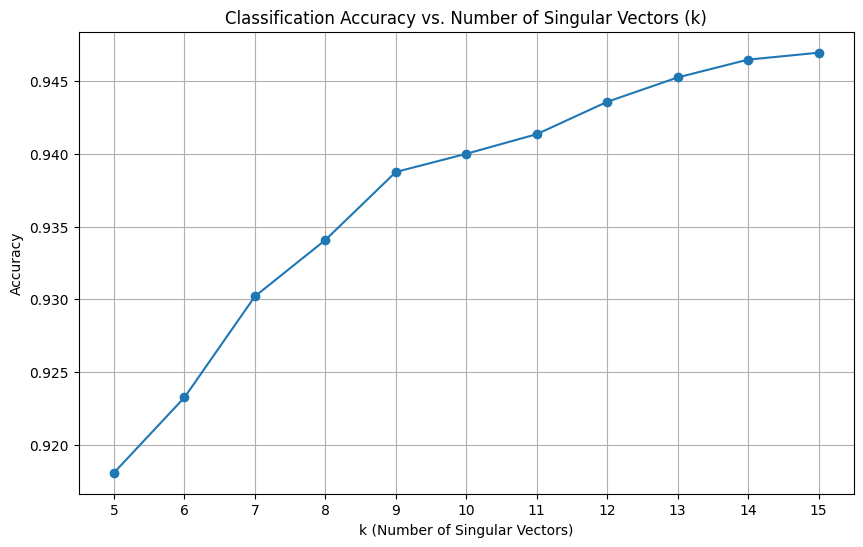

Classification complete and accuracy plotted.


In [38]:
k_values = range(5, max_k + 1) # k from 5 to 15
accuracies = []

print(f"Starting classification for k values from {min(k_values)} to {max(k_values)}...")

for k in k_values:
    accuracy = classify_and_evaluate(TestMat, TestLabels, Uk_matrices, k)
    accuracies.append(accuracy)
    print(f"k = {k}: Accuracy = {accuracy:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('Classification Accuracy vs. Number of Singular Vectors (k)')
plt.xlabel('k (Number of Singular Vectors)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xticks(k_values)
plt.show()

print("Classification complete and accuracy plotted.")

Vi har nu framgångsrikt gått igenom och implementerat SVD-baserad klassificering. Vi har förklarat konceptet med singulära bilder och residualer, förberett och förberäknat U_k-matriserna för varje siffra, verifierat att datastrukturerna är korrekta, implementerat en optimerad klassificeringsalgoritm med matris-matris-multiplikation och slutligen analyserat och visualiserat klassificeringsnoggrannheten för olika k-värden. Resultaten visar att noggrannheten ökar med fler singulära vektorer, vilket förväntas.

In [ ]:
# Use different values k = 5, 6, . . . , 15 (number of basis functions),
# and report the percentage of the success of this SVD-based algorithm
# for each digit with different k values separately.

In [39]:
def classify_and_evaluate_per_digit(test_mat, test_labels, Uk_matrices_all_digits, k_value):
    """
    Classify test digits using SVD-based method and evaluate accuracy for each digit.

    Args:
        test_mat (np.ndarray): The matrix of test digits (m x num_test_digits).
        test_labels (np.ndarray): True labels for test digits.
        Uk_matrices_all_digits (dict): Dictionary with U_k matrices for all digits.
        k_value (int): The number of singular vectors to use for classification.

    Returns:
        dict: A dictionary where keys are digits (0-9) and values are their classification accuracies.
    """
    num_test_digits = test_mat.shape[1]
    num_classes = len(Uk_matrices_all_digits)

    all_residuals = np.zeros((num_classes, num_test_digits))

    for digit_class in range(num_classes):
        if digit_class in Uk_matrices_all_digits:
            U_k_for_class = Uk_matrices_all_digits[digit_class]
            all_residuals[digit_class, :] = calculate_residuals(test_mat, U_k_for_class, k_value)
        else:
            all_residuals[digit_class, :] = np.inf

    predicted_labels = np.argmin(all_residuals, axis=0)

    per_digit_accuracy = {}
    for digit in range(num_classes):
        indices_for_digit = np.where(test_labels[0] == digit)[0]
        if len(indices_for_digit) == 0:
            per_digit_accuracy[digit] = np.nan  # No test samples for this digit
            continue

        predictions_for_digit = predicted_labels[indices_for_digit]
        true_labels_for_digit = test_labels[0][indices_for_digit]

        correct_predictions_for_digit = np.sum(predictions_for_digit == true_labels_for_digit)
        accuracy_for_digit = correct_predictions_for_digit / len(indices_for_digit)
        per_digit_accuracy[digit] = accuracy_for_digit

    return per_digit_accuracy

print("Per-digit classification function defined.")

Per-digit classification function defined.


Nu ska vi beräkna och visa noggrannheten för varje siffra separat för varje `k`-värde.

Starting per-digit classification for k values from 5 to 15...
k          Digit 0    Digit 1    Digit 2    Digit 3    Digit 4    Digit 5    Digit 6    Digit 7    Digit 8    Digit 9   
------------------------------------------------------------------------------------------------------------------------
5          0.9600      0.9670      0.9058      0.9160      0.8925      0.9153      0.9567      0.8955      0.8672      0.9048     
6          0.9695      0.9750      0.9123      0.9200      0.8980      0.9113      0.9480      0.9143      0.8710      0.9133     
7          0.9748      0.9765      0.9170      0.9260      0.9150      0.9167      0.9557      0.9297      0.8708      0.9197     
8          0.9745      0.9772      0.9213      0.9287      0.9175      0.9207      0.9585      0.9307      0.8812      0.9303     
9          0.9750      0.9788      0.9270      0.9385      0.9255      0.9265      0.9613      0.9327      0.8892      0.9330     
10         0.9722      0.9795      0.927

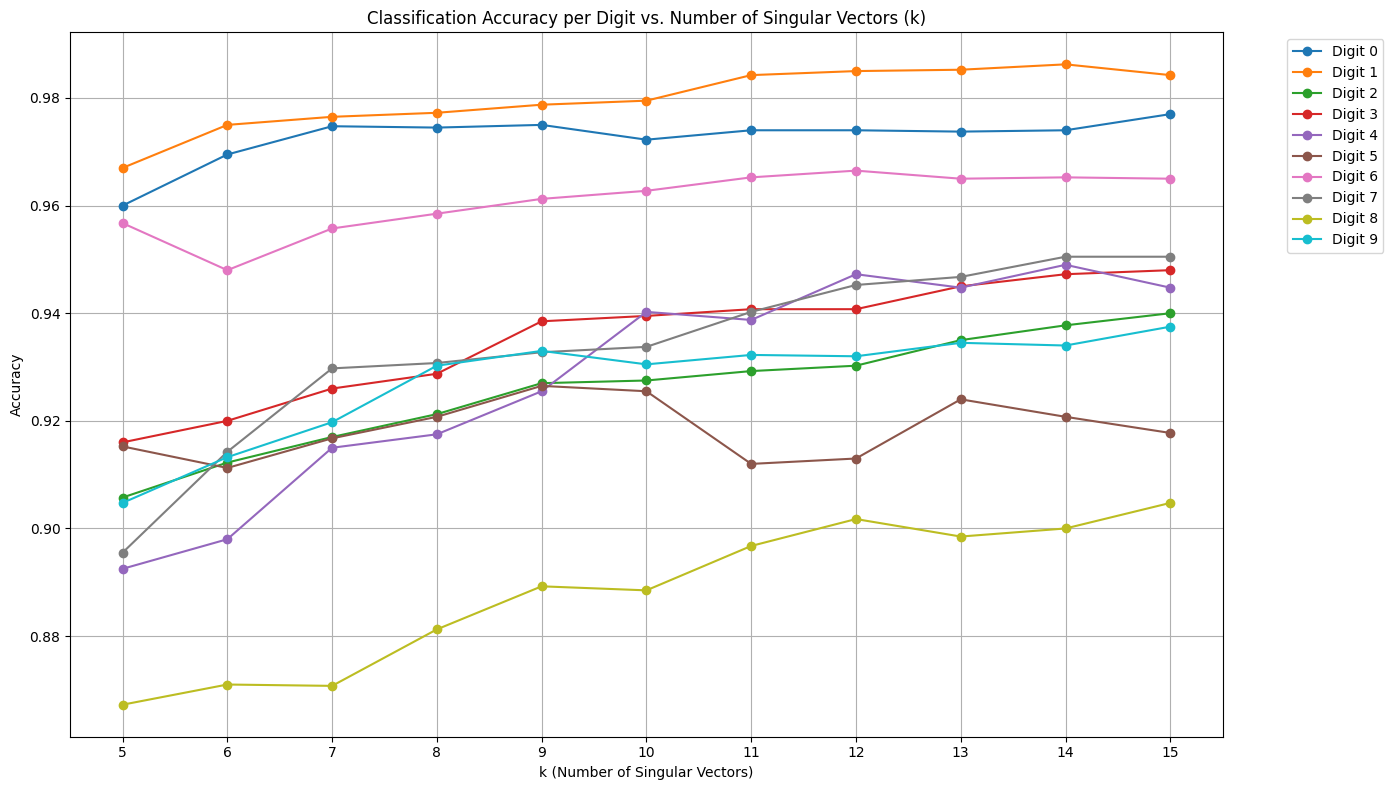

Per-digit accuracy plot generated.


In [40]:
k_values = range(5, max_k + 1) # k from 5 to 15
per_digit_accuracies_over_k = {digit: [] for digit in range(10)}

print(f"Starting per-digit classification for k values from {min(k_values)} to {max(k_values)}...")

# Prepare to print results in a structured way
header = ["k"] + [f"Digit {d}" for d in range(10)]
print(" ".join([f'{h:<10}' for h in header]))
print("-" * (10 * (len(header) + 1)))

for k in k_values:
    accuracies_for_k = classify_and_evaluate_per_digit(TestMat, TestLabels, Uk_matrices, k)
    row_output = [f'{k:<10}']
    for digit in range(10):
        accuracy = accuracies_for_k.get(digit, np.nan)
        per_digit_accuracies_over_k[digit].append(accuracy)
        row_output.append(f'{accuracy:.4f}{'':<5}')
    print(" ".join(row_output))

print("\nPer-digit classification complete. Plotting results...")

plt.figure(figsize=(14, 8))
for digit in range(10):
    plt.plot(k_values, per_digit_accuracies_over_k[digit], marker='o', label=f'Digit {digit}')

plt.title('Classification Accuracy per Digit vs. Number of Singular Vectors (k)')
plt.xlabel('k (Number of Singular Vectors)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xticks(k_values)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Per-digit accuracy plot generated.")